In [107]:
import numpy as np
import matplotlib.pyplot as plt

# define the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [108]:
# Loss function: Log likelihood

def compute_loss(y, hx):
    return -np.mean(y * np.log(hx) + (1 - y) * np.log(1 - hx))

In [109]:
# gradient of the loss

def compute_gradient(X, y, hx):
    return np.dot(X.T, (hx - y)) / y.shape[0]   # y.shape[0] added because it calculate no of data points we have and we need to divide by that to get the average gradient

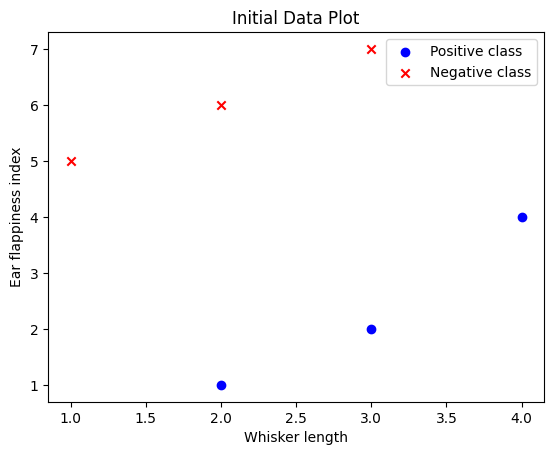

In [110]:
# Dataset
X = np.array([
    [2, 1],
    [3, 2],
    [4, 4],  # Positive examples
    [1, 5],
    [2, 6],
    [3, 7]   # Negative examples
])

y = np.array([1, 1, 1, 0, 0, 0])  # Labels

# Plot initial data
plt.scatter(X[:3, 0], X[:3, 1], color='blue', marker='o', label='Positive class')
plt.scatter(X[3:, 0], X[3:, 1], color='red', marker='x', label='Negative class')

plt.xlabel('Whisker length')
plt.ylabel('Ear flappiness index')
plt.legend()
plt.title('Initial Data Plot')
plt.show()

In [111]:
# Plotting function for decision boundary
def plot_decision_boundary(X, y, weights, loss, iteration):
    plt.scatter(X[:3, 1], X[:3, 2], color='blue', marker='o',
                label='Positive class' if iteration == 0 else "")
    plt.scatter(X[3:, 1], X[3:, 2], color='red', marker='x',
                label='Negative class' if iteration == 0 else "")

    # Extend the x values a bit beyond the minimum and maximum values of the dataset
    x_values = np.array([np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1])
    y_values = -(weights[0] + weights[1] * x_values) / weights[2]

    plt.plot(x_values, y_values, "k")

    plt.xlim(x_values[0], x_values[1])
    plt.ylim(np.min(X[:, 2]) - 1, np.max(X[:, 2]) + 1)
    plt.xlabel('Whisker length')
    plt.ylabel('Ear flappiness index')
    plt.title(f"Decision boundary at iteration {iteration}\nLoss: {loss}")

    if iteration == 0:
        plt.legend()

    plt.show()
        

In [112]:
def plot_decision_boundary(X, y, weights, loss, iteration):

    # Plot positive and negative classes
    plt.scatter(X[y == 1, 0], X[y == 1, 1],
                color='blue', marker='o',
                label='Positive class' if iteration == 0 else "")

    plt.scatter(X[y == 0, 0], X[y == 0, 1],
                color='red', marker='x',
                label='Negative class' if iteration == 0 else "")

    # Create range for x values
    x_values = np.array([np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1])

    # Decision boundary line: w0 + w1*x1 + w2*x2 = 0
    if weights[2] != 0:
        y_values = -(weights[0] + weights[1] * x_values) / weights[2]
        plt.plot(x_values, y_values, "k")

    # Axis limits
    plt.xlim(np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1)
    plt.ylim(np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1)

    # Labels
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.title(f"Decision Boundary at Iteration {iteration}\nLoss: {loss}")

    if iteration == 0:
        plt.legend()

    plt.show()

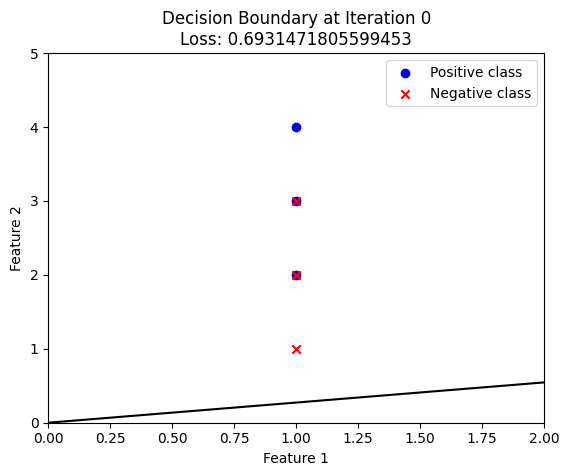

Iteration 0: Theta =[ 0.          0.025      -0.09166667], Loss = 0.6931471805599453


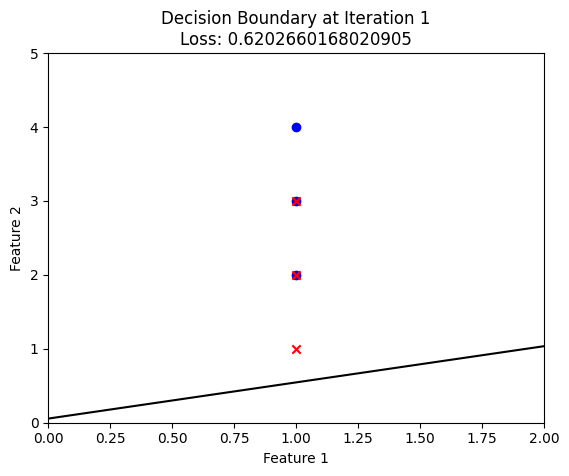

Iteration 1: Theta =[ 0.00784781  0.06887779 -0.14060525], Loss = 0.6202660168020905


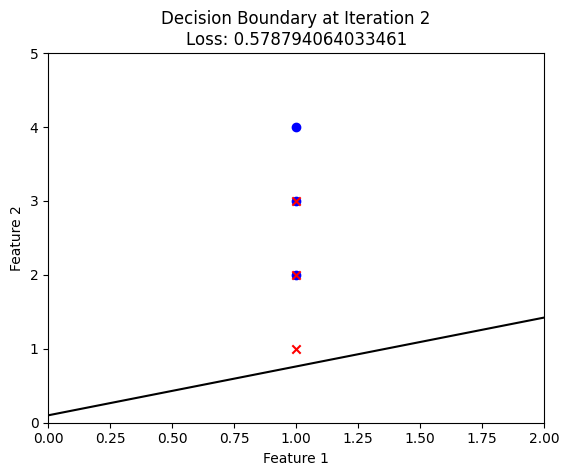

Iteration 2: Theta =[ 0.01764134  0.11658362 -0.17629863], Loss = 0.578794064033461


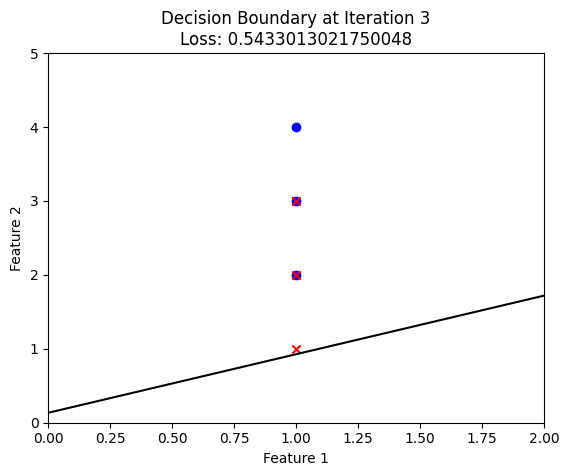

Iteration 3: Theta =[ 0.02775584  0.16401158 -0.20689154], Loss = 0.5433013021750048


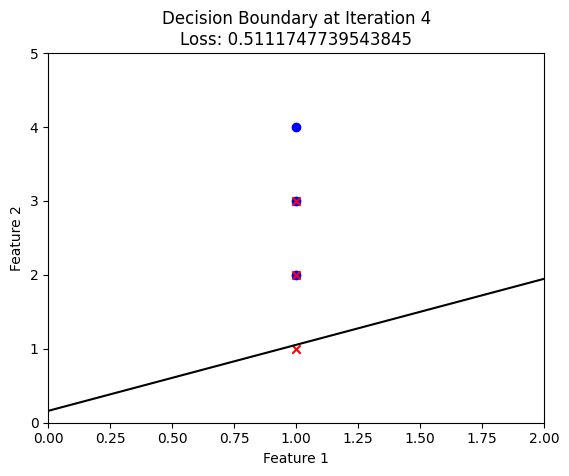

Iteration 4: Theta =[ 0.03768945  0.20992896 -0.23499581], Loss = 0.5111747739543845


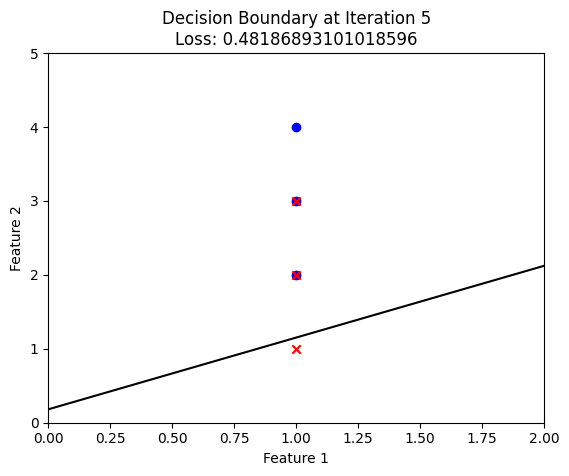

Iteration 5: Theta =[ 0.04728565  0.25399034 -0.26154053], Loss = 0.48186893101018596


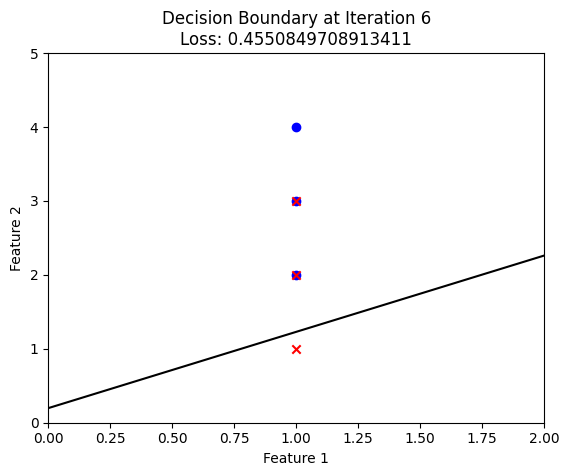

Iteration 6: Theta =[ 0.0565048   0.29615111 -0.28688777], Loss = 0.4550849708913411


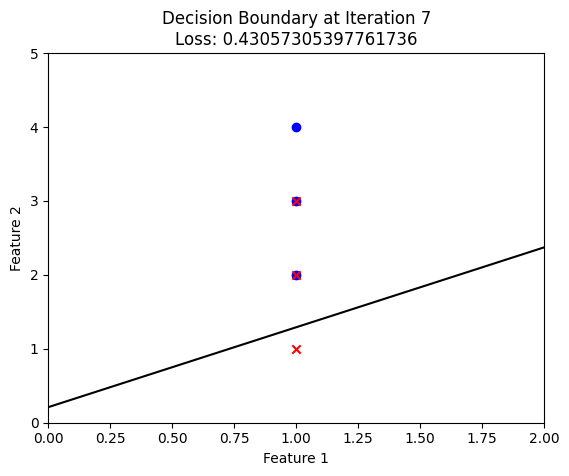

Iteration 7: Theta =[ 0.06534809  0.33647087 -0.31119923], Loss = 0.43057305397761736


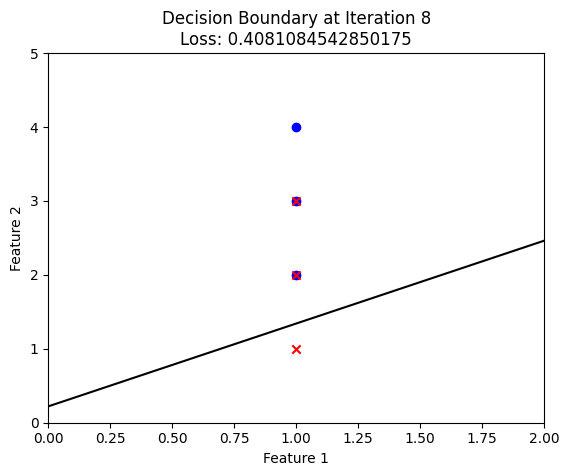

Iteration 8: Theta =[ 0.07383072  0.37504349 -0.3345636 ], Loss = 0.4081084542850175


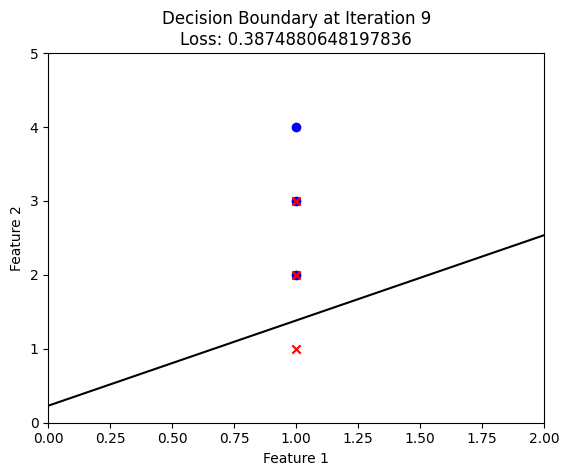

Iteration 9: Theta =[ 0.08197221  0.41197135 -0.35704216], Loss = 0.3874880648197836


In [113]:
# Train the model

weights = logistic_regression(X, y, learning_rate=0.1, num_iterations=10)

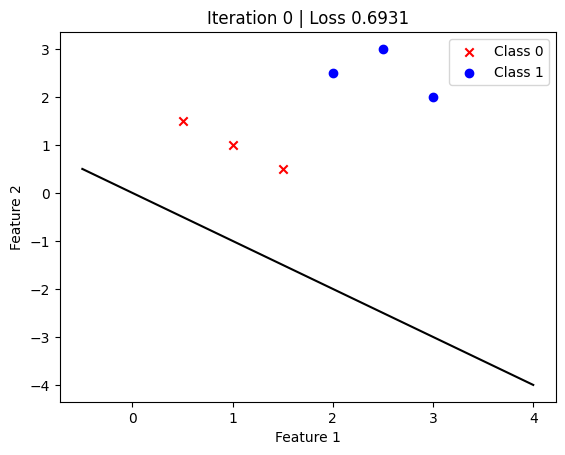

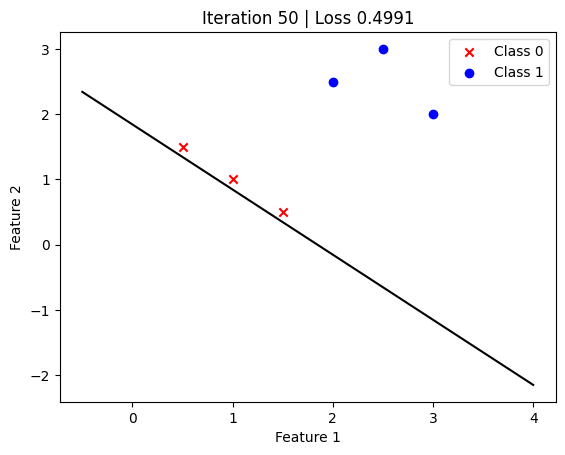

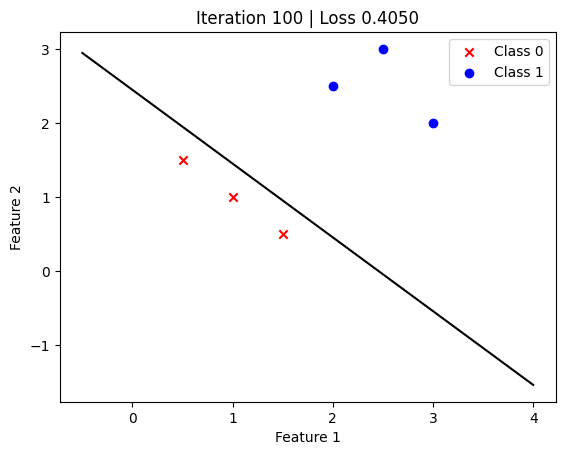

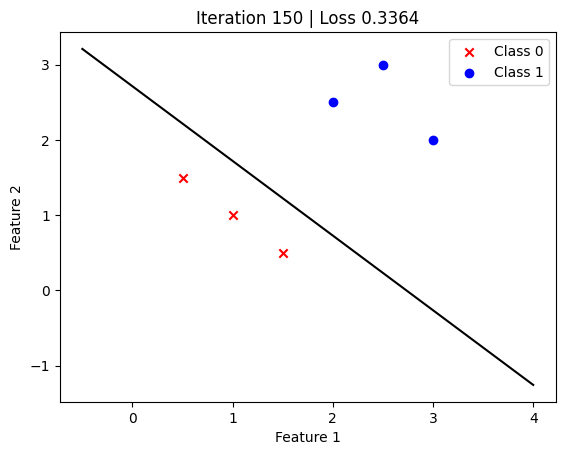

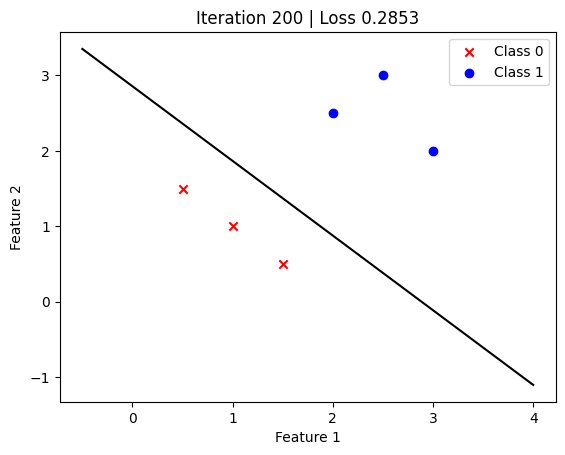

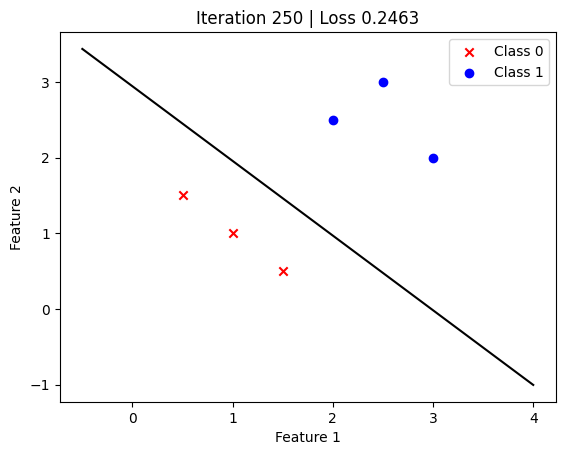

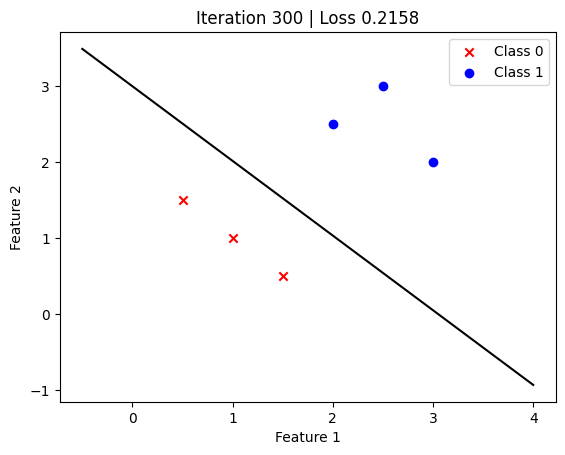

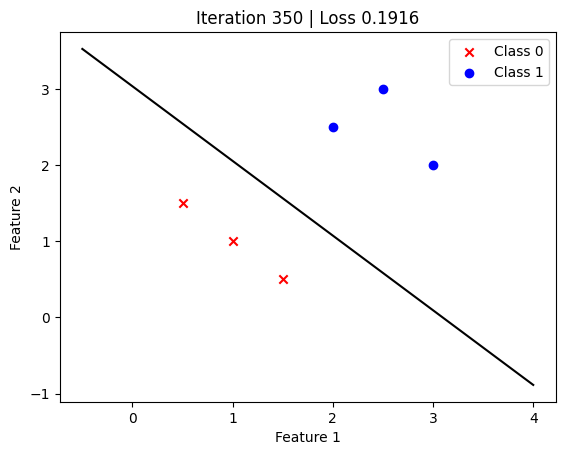

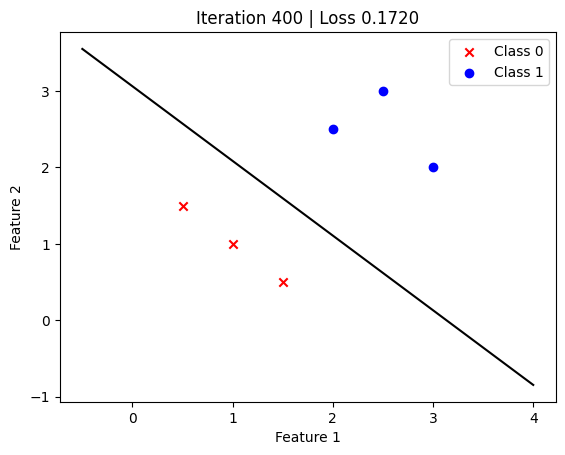

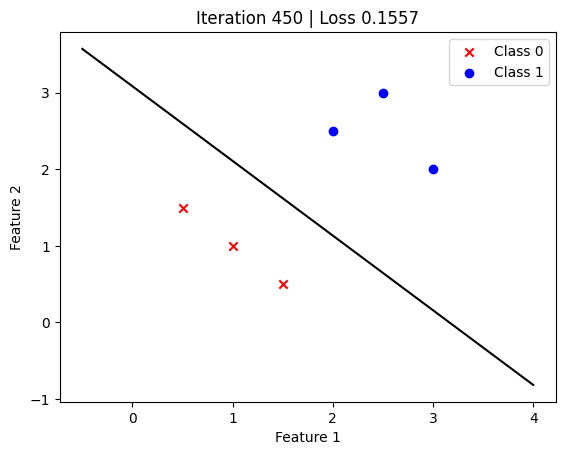

Final Weights: [-4.22842401  1.32750671  1.36470246]


In [118]:
import numpy as np
import matplotlib.pyplot as plt


# Dataset
X = np.array([
    [0.5, 1.5],
    [1.0, 1.0],
    [1.5, 0.5],
    [3.0, 2.0],
    [2.0, 2.5],
    [2.5, 3.0]
])

y = np.array([0,0,0,1,1,1])

# Add bias term
X = np.c_[np.ones(X.shape[0]), X]


# Sigmoid function
def sigmoid(z):
    return 1/(1 + np.exp(-z))


# Prediction
def predict(X, weights):
    z = np.dot(X, weights)
    return sigmoid(z)


# Loss function
def compute_loss(y, y_pred):

    m = len(y)

    loss = -(1/m) * np.sum(
        y*np.log(y_pred + 1e-9) +
        (1-y)*np.log(1-y_pred + 1e-9)
    )

    return loss


# Decision boundary plot
def plot_decision_boundary(X, y, weights, loss, iteration):

    plt.clf()

    plt.scatter(X[y==0,1], X[y==0,2], color='red', marker='x', label="Class 0")
    plt.scatter(X[y==1,1], X[y==1,2], color='blue', marker='o', label="Class 1")

    x_values = np.array([
        np.min(X[:,1]) - 1,
        np.max(X[:,1]) + 1
    ])

    if weights[2] != 0:
        y_values = -(weights[0] + weights[1]*x_values)/weights[2]
        plt.plot(x_values, y_values, 'k')

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.title(f"Iteration {iteration} | Loss {loss:.4f}")

    plt.legend()

    plt.pause(0.1)


# Training (Gradient Descent)
def train(X, y, lr=0.1, iterations=500):

    m, n = X.shape
    weights = np.zeros(n)

    plt.figure()

    for i in range(iterations):

        y_pred = predict(X, weights)

        loss = compute_loss(y, y_pred)

        gradient = (1/m) * np.dot(X.T, (y_pred - y))

        weights = weights - lr * gradient

        if i % 50 == 0:
            plot_decision_boundary(X, y, weights, loss, i)

    plt.show()

    return weights


# Run training
weights = train(X, y, lr=0.1, iterations=500)

print("Final Weights:", weights)